#MTH 5000 – Applied Forecasting of Financial Data
##Lecture 4:
##Part 2: Preprocessing, EDA, and Visualization
---
Topics

*  1. Preprocessing Financial Data
*  2. Basic Exploration (EDA)
*  3. Visualization
*  4. Saving Our Work



In [3]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving fetch_data.py to fetch_data.py
User uploaded file "fetch_data.py" with length 1110 bytes


In [4]:
import fetch_data
from fetch_data import get_weekly_data


In [5]:
fetch_data_df = get_weekly_data("AMZN", start="2015-01-01", end = "2025-12-30",keep_columns=["Close"])

print(fetch_data_df.head())

Price           Close       High      Low     Open      Volume
Ticker           AMZN       AMZN     AMZN     AMZN        AMZN
Date                                                          
2015-01-01  14.921000  15.737500  14.6190  15.6290   234334000
2015-01-08  14.663500  15.157000  14.3250  15.0160   375546000
2015-01-15  14.862500  15.300000  14.2625  14.7000   420752000
2015-01-22  15.195500  15.846500  15.0000  15.0000   380256000
2015-01-29  18.237499  18.391001  14.9665  15.2365  1062542000


#1. Preprocessing Financial Data

In [6]:
import pandas as pd

In [7]:
df = fetch_data_df

Check for missing values

In [8]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AMZN,0
High,AMZN,0
Low,AMZN,0
Open,AMZN,0
Volume,AMZN,0


#2. Basic Exploration (EDA)


##Let us define a new Statistic Called **Return** that measures percent change in closing prices.

In [9]:
#fetch_data_df = get_weekly_data("AMZN", start="2015-01-01", end = "2025-12-30",keep_columns=["Close"])
#df = fetch_data_df

df["Return"] = df["Close"].pct_change()


$$
\text{Return}_t = \frac{\text{Close}_{t} - \text{Close}_{t-1}}{\text{Close}_{t-1}}
$$

Which represents the percent change from previous week to current week.

In [10]:
df

Price,Close,High,Low,Open,Volume,Return
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,
Date,,,,,,
2015-01-01,14.921000,15.737500,14.619000,15.629000,234334000,NaN
2015-01-08,14.663500,15.157000,14.325000,15.016000,375546000,-0.017258
2015-01-15,14.862500,15.300000,14.262500,14.700000,420752000,0.013571
2015-01-22,15.195500,15.846500,15.000000,15.000000,380256000,0.022405
2015-01-29,18.237499,18.391001,14.966500,15.236500,1062542000,0.200191
...,...,...,...,...,...,...
2025-11-27,232.380005,238.970001,230.220001,231.240005,144476800,0.014051
2025-12-04,231.779999,233.500000,225.110001,232.770004,178452200,-0.002582


Identify Extreme Return Outliers

In [11]:
pd.set_option('display.float_format', '{:.6f}'.format) #For formating as non scientific

largest_returns = df.nlargest(5, "Return")["Return"] #Displaying top 5 returns
samllest_returns = df.nsmallest(5, "Return")["Return"] #Displaying bottom 5 returns

print("Largest Returns:")
print(largest_returns)

print("\nSmallest Returns:")
print(samllest_returns)



Largest Returns:
Date
2015-01-29   0.200191
2022-07-28   0.153344
2022-05-26   0.139630
2017-10-26   0.134411
2020-04-09   0.129555
Name: Return, dtype: float64

Smallest Returns:
Date
2022-10-27   -0.203528
2022-05-05   -0.163239
2024-08-01   -0.129479
2022-01-20   -0.111495
2022-06-09   -0.111487
Name: Return, dtype: float64


In [12]:
pd.set_option('display.float_format', '{:.6f}'.format)
max_row = df.loc[df["Return"].idxmax()] #Max return instance
min_row = df.loc[df["Return"].idxmin()] #Min return instance

print("Largest Return:")
print(max_row)

print("\nSmallest Return:")
print(min_row)

Largest Return:
Price   Ticker
Close   AMZN             18.237499
High    AMZN             18.391001
Low     AMZN             14.966500
Open    AMZN             15.236500
Volume  AMZN     1062542000.000000
Return                    0.200191
Name: 2015-01-29 00:00:00, dtype: float64

Smallest Return:
Price   Ticker
Close   AMZN            92.120003
High    AMZN           114.120003
Low     AMZN            92.010002
Open    AMZN           113.919998
Volume  AMZN     741122000.000000
Return                  -0.203528
Name: 2022-10-27 00:00:00, dtype: float64


In [13]:
print("Largest Return: {:.2f}%".format(df["Return"].max() * 100))
print("Smallest Return: {:.2f}%".format(df["Return"].min() * 100))

Largest Return: 20.02%
Smallest Return: -20.35%


##Defining a new intuitive Statistic called **Open-Close Difference** that measures weekly price move.

In [14]:
df["Open_Close_Diff"] = df["Open"] - df["Close"]

$$
\text{Open-Close Difference} = \text{Open - Close}
$$

In [15]:
df

Price,Close,High,Low,Open,Volume,Return,Open_Close_Diff
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,,
Date,,,,,,,
2015-01-01,14.921000,15.737500,14.619000,15.629000,234334000,NaN,0.708000
2015-01-08,14.663500,15.157000,14.325000,15.016000,375546000,-0.017258,0.352500
2015-01-15,14.862500,15.300000,14.262500,14.700000,420752000,0.013571,-0.162500
2015-01-22,15.195500,15.846500,15.000000,15.000000,380256000,0.022405,-0.195500
2015-01-29,18.237499,18.391001,14.966500,15.236500,1062542000,0.200191,-3.000999
...,...,...,...,...,...,...,...
2025-11-27,232.380005,238.970001,230.220001,231.240005,144476800,0.014051,-1.139999
2025-12-04,231.779999,233.500000,225.110001,232.770004,178452200,-0.002582,0.990005


## Let us again define a new intuitive Statistic called **High-Low** Difference that measures intraday volatility.

Where intraday volatility measures how much the price of a stock fluctuates within a single trading period (e.g., one day or one week).

In [16]:
df["High_Low"] = df["High"] - df["Low"]

$$
\text{High-Low Difference} = \text{High Price} - \text{Low Price}
$$

## Finally we will define a new intuitive Statistic called **Absolute Return** Difference that measures Magnitude of movement without direction.

In [17]:
df["Abs_Return"] = df["Return"].abs()

In [18]:
df

Price,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,,,,
Date,,,,,,,,,
2015-01-01,14.921000,15.737500,14.619000,15.629000,234334000,NaN,0.708000,1.118500,NaN
2015-01-08,14.663500,15.157000,14.325000,15.016000,375546000,-0.017258,0.352500,0.832000,0.017258
2015-01-15,14.862500,15.300000,14.262500,14.700000,420752000,0.013571,-0.162500,1.037500,0.013571
2015-01-22,15.195500,15.846500,15.000000,15.000000,380256000,0.022405,-0.195500,0.846500,0.022405
2015-01-29,18.237499,18.391001,14.966500,15.236500,1062542000,0.200191,-3.000999,3.424500,0.200191
...,...,...,...,...,...,...,...,...,...
2025-11-27,232.380005,238.970001,230.220001,231.240005,144476800,0.014051,-1.139999,8.750000,0.014051
2025-12-04,231.779999,233.500000,225.110001,232.770004,178452200,-0.002582,0.990005,8.389999,0.002582


In [19]:
largest_absolute_returns = df.nlargest(10, "Abs_Return")["Abs_Return"]
largest_absolute_returns

,Abs_Return
Date,
2022-10-27,0.203528
2015-01-29,0.200191
2022-05-05,0.163239
2022-07-28,0.153344
2022-05-26,0.139630
2017-10-26,0.134411
2020-04-09,0.129555
2024-08-01,0.129479
2023-10-26,0.128594


## Thus we have defined the following informative statistics
**Return** → percent change

**Open-Close Difference** → daily price move

**High-Low Difference** → intraday volatility

**Absolute Return** → risk magnitude

##Cleaning and Summary Statistics of our dataset

In [20]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AMZN,0
High,AMZN,0
Low,AMZN,0
Open,AMZN,0
Volume,AMZN,0
Return,,1
Open_Close_Diff,,0
High_Low,,0
Abs_Return,,1


In [21]:
df = df.round(3)
df

Price,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,,,,
Date,,,,,,,,,
2015-01-01,14.921000,15.738000,14.619000,15.629000,234334000,NaN,0.708000,1.118000,NaN
2015-01-08,14.663000,15.157000,14.325000,15.016000,375546000,-0.017000,0.352000,0.832000,0.017000
2015-01-15,14.863000,15.300000,14.262000,14.700000,420752000,0.014000,-0.163000,1.038000,0.014000
2015-01-22,15.196000,15.847000,15.000000,15.000000,380256000,0.022000,-0.196000,0.847000,0.022000
2015-01-29,18.237000,18.391000,14.967000,15.236000,1062542000,0.200000,-3.001000,3.425000,0.200000
...,...,...,...,...,...,...,...,...,...
2025-11-27,232.380000,238.970000,230.220000,231.240000,144476800,0.014000,-1.140000,8.750000,0.014000
2025-12-04,231.780000,233.500000,225.110000,232.770000,178452200,-0.003000,0.990000,8.390000,0.003000


In [22]:
print(df.columns)
df.columns = df.columns.droplevel('Ticker')

MultiIndex([(          'Close', 'AMZN'),
            (           'High', 'AMZN'),
            (            'Low', 'AMZN'),
            (           'Open', 'AMZN'),
            (         'Volume', 'AMZN'),
            (         'Return',     ''),
            ('Open_Close_Diff',     ''),
            (       'High_Low',     ''),
            (     'Abs_Return',     '')],
           names=['Price', 'Ticker'])


In [23]:
df

Price,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
Date,,,,,,,,,
2015-01-01,14.921000,15.738000,14.619000,15.629000,234334000,NaN,0.708000,1.118000,NaN
2015-01-08,14.663000,15.157000,14.325000,15.016000,375546000,-0.017000,0.352000,0.832000,0.017000
2015-01-15,14.863000,15.300000,14.262000,14.700000,420752000,0.014000,-0.163000,1.038000,0.014000
2015-01-22,15.196000,15.847000,15.000000,15.000000,380256000,0.022000,-0.196000,0.847000,0.022000
2015-01-29,18.237000,18.391000,14.967000,15.236000,1062542000,0.200000,-3.001000,3.425000,0.200000
...,...,...,...,...,...,...,...,...,...
2025-11-27,232.380000,238.970000,230.220000,231.240000,144476800,0.014000,-1.140000,8.750000,0.014000
2025-12-04,231.780000,233.500000,225.110000,232.770000,178452200,-0.003000,0.990000,8.390000,0.003000
2025-12-11,221.270000,232.110000,220.990000,230.710000,194508100,-0.045000,9.440000,11.120000,0.045000


In [24]:
df.columns.name = None

In [25]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [26]:
df

,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
Date,,,,,,,,,
2015-01-01,14.921000,15.738000,14.619000,15.629000,234334000,NaN,0.708000,1.118000,NaN
2015-01-08,14.663000,15.157000,14.325000,15.016000,375546000,-0.017000,0.352000,0.832000,0.017000
2015-01-15,14.863000,15.300000,14.262000,14.700000,420752000,0.014000,-0.163000,1.038000,0.014000
2015-01-22,15.196000,15.847000,15.000000,15.000000,380256000,0.022000,-0.196000,0.847000,0.022000
2015-01-29,18.237000,18.391000,14.967000,15.236000,1062542000,0.200000,-3.001000,3.425000,0.200000
...,...,...,...,...,...,...,...,...,...
2025-11-27,232.380000,238.970000,230.220000,231.240000,144476800,0.014000,-1.140000,8.750000,0.014000
2025-12-04,231.780000,233.500000,225.110000,232.770000,178452200,-0.003000,0.990000,8.390000,0.003000
2025-12-11,221.270000,232.110000,220.990000,230.710000,194508100,-0.045000,9.440000,11.120000,0.045000


In [27]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'Open_Close_Diff',
       'High_Low', 'Abs_Return'],
      dtype='object')

In [28]:
df

,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
Date,,,,,,,,,
2015-01-01,14.921000,15.738000,14.619000,15.629000,234334000,NaN,0.708000,1.118000,NaN
2015-01-08,14.663000,15.157000,14.325000,15.016000,375546000,-0.017000,0.352000,0.832000,0.017000
2015-01-15,14.863000,15.300000,14.262000,14.700000,420752000,0.014000,-0.163000,1.038000,0.014000
2015-01-22,15.196000,15.847000,15.000000,15.000000,380256000,0.022000,-0.196000,0.847000,0.022000
2015-01-29,18.237000,18.391000,14.967000,15.236000,1062542000,0.200000,-3.001000,3.425000,0.200000
...,...,...,...,...,...,...,...,...,...
2025-11-27,232.380000,238.970000,230.220000,231.240000,144476800,0.014000,-1.140000,8.750000,0.014000
2025-12-04,231.780000,233.500000,225.110000,232.770000,178452200,-0.003000,0.990000,8.390000,0.003000
2025-12-11,221.270000,232.110000,220.990000,230.710000,194508100,-0.045000,9.440000,11.120000,0.045000


In [29]:
df.describe()

,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
count,574.000000,574.000000,574.000000,574.000000,574.000000,573.000000,574.000000,574.000000,573.000000
mean,112.020927,115.169862,108.275321,111.790843,353077089.372822,0.005742,-0.230085,6.894538,0.031766
std,61.912096,63.624569,59.982286,61.970673,164514758.067474,0.043077,5.330910,5.530512,0.029627
min,14.663000,15.157000,14.262000,14.700000,57703100.000000,-0.204000,-23.140000,0.450000,0.000000
25%,50.370500,51.231750,49.221000,50.141000,242882950.000000,-0.016000,-2.186500,2.314750,0.011000
50%,99.823000,102.150000,96.277500,99.935500,310555000.000000,0.008000,-0.367500,6.134500,0.023000
75%,163.370500,167.135500,158.412500,163.749750,429915500.000000,0.028000,1.478250,9.620000,0.043000
max,250.200000,258.600000,238.490000,249.160000,1219318000.000000,0.200000,26.520000,38.990000,0.204000


In [30]:
df

,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
Date,,,,,,,,,
2015-01-01,14.921000,15.738000,14.619000,15.629000,234334000,NaN,0.708000,1.118000,NaN
2015-01-08,14.663000,15.157000,14.325000,15.016000,375546000,-0.017000,0.352000,0.832000,0.017000
2015-01-15,14.863000,15.300000,14.262000,14.700000,420752000,0.014000,-0.163000,1.038000,0.014000
2015-01-22,15.196000,15.847000,15.000000,15.000000,380256000,0.022000,-0.196000,0.847000,0.022000
2015-01-29,18.237000,18.391000,14.967000,15.236000,1062542000,0.200000,-3.001000,3.425000,0.200000
...,...,...,...,...,...,...,...,...,...
2025-11-27,232.380000,238.970000,230.220000,231.240000,144476800,0.014000,-1.140000,8.750000,0.014000
2025-12-04,231.780000,233.500000,225.110000,232.770000,178452200,-0.003000,0.990000,8.390000,0.003000
2025-12-11,221.270000,232.110000,220.990000,230.710000,194508100,-0.045000,9.440000,11.120000,0.045000


**Questions of intrest**

What is the average price?

What is the max price?

How volatile is it?

#3. Visualization

### 1. Closing Price Over Time


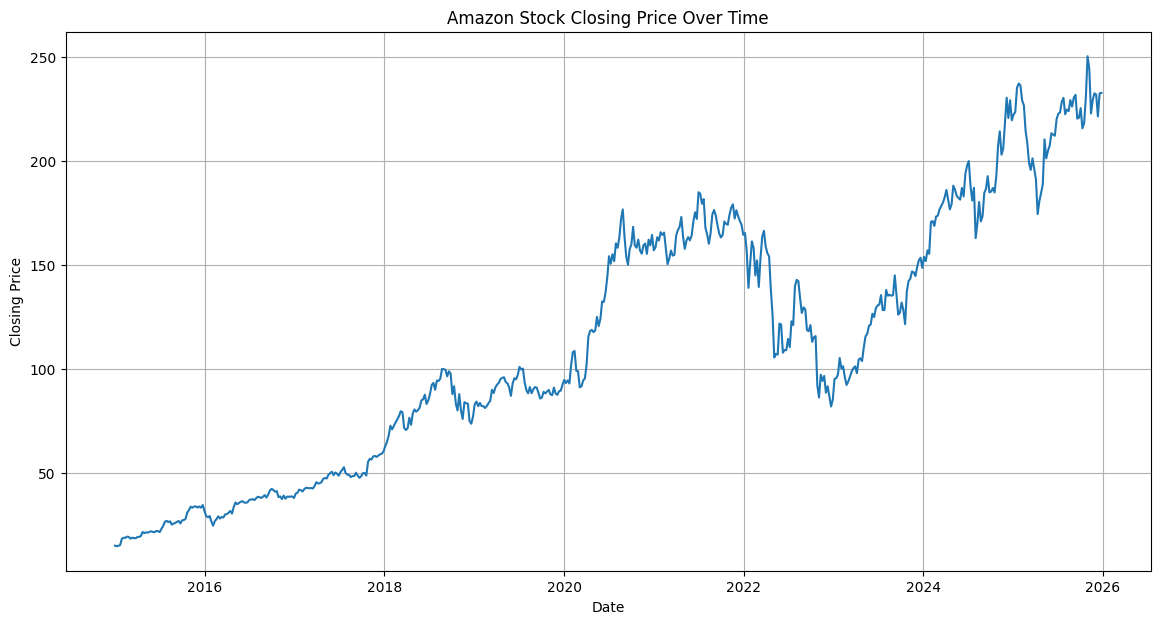

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x=df.index, y= df['Close'], legend=False)
plt.title('Amazon Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

This plot shows the trend of the stock's closing price over the entire period, allowing us to observe its historical performance.

### 2. Distribution of Returns


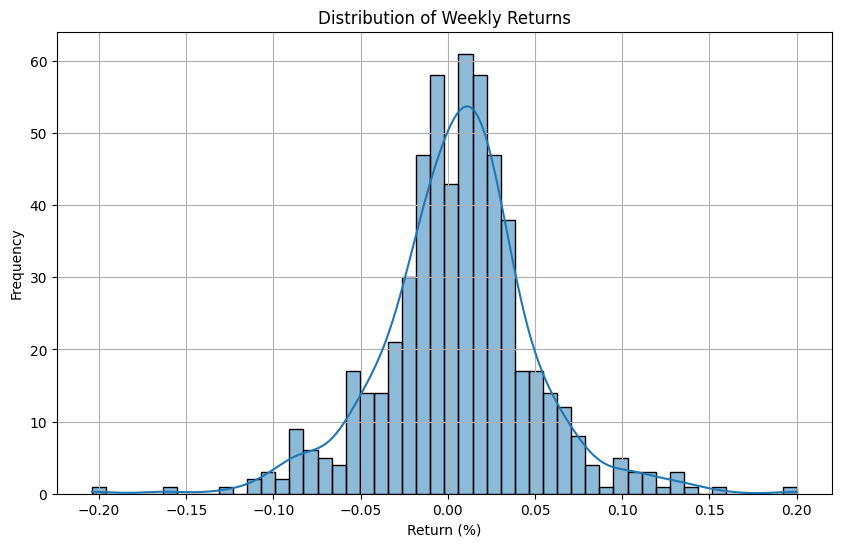

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Return'].dropna(), bins=50, kde=True)
plt.title('Distribution of Weekly Returns')
plt.xlabel('Return (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

A histogram of the 'Return' column helps visualize the frequency of different percentage changes, giving insights into the stock's volatility and common price movements.

### 3. High-Low Difference Over Time


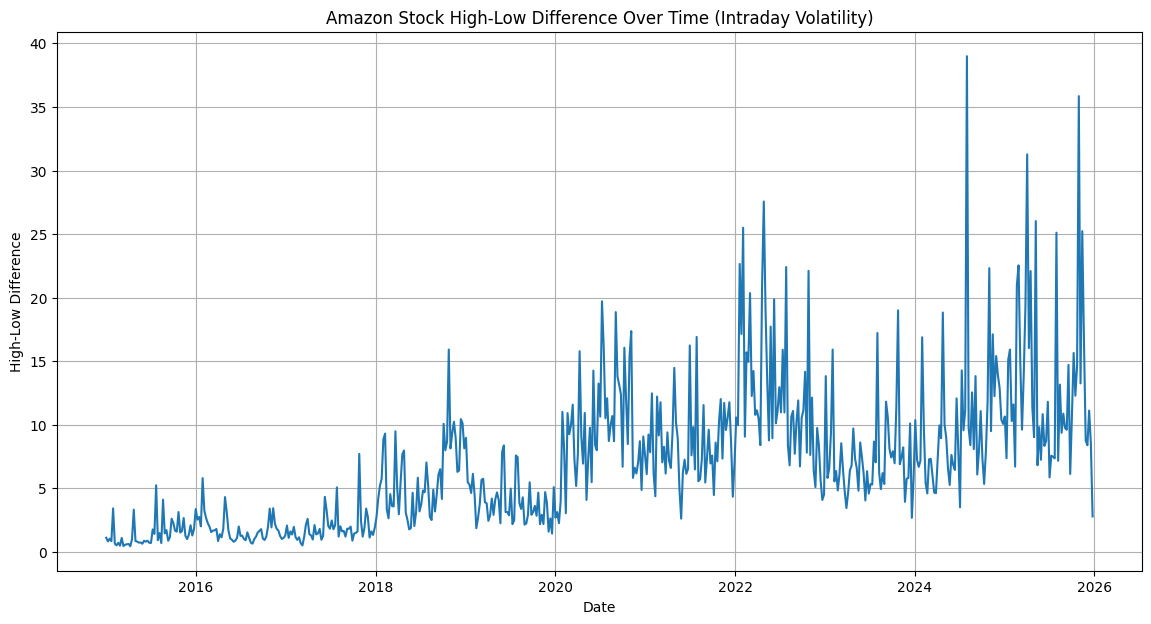

In [33]:
plt.figure(figsize=(14, 7))
sns.lineplot(x=df.index, y=df['High_Low'], legend=False)
plt.title('Amazon Stock High-Low Difference Over Time (Intraday Volatility)')
plt.xlabel('Date')
plt.ylabel('High-Low Difference')
plt.grid(True)
plt.show()

This plot illustrates the 'High-Low Difference', which represents the intraday (or in this case, intra-week) volatility of the stock over time.

### 4. Distribution of Open-Close Difference


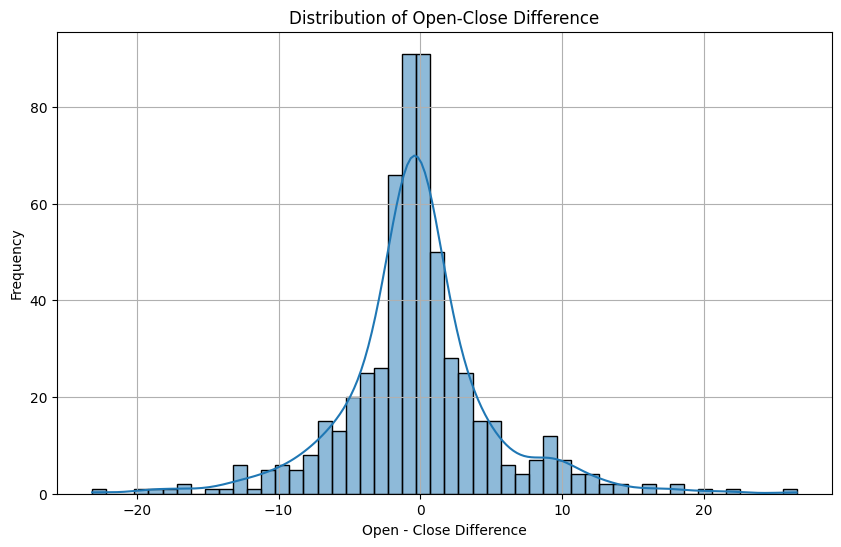

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Open_Close_Diff'].dropna(), bins=50, kde=True)
plt.title('Distribution of Open-Close Difference')
plt.xlabel('Open - Close Difference')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


A histogram of the 'Open-Close Difference' shows how often the stock closes higher or lower than its opening price, indicating weekly directional bias.

# 4. Saving Our Work

In [35]:
from google.colab import files

# Save to CSV
df.to_csv("Forecasting_Cleaned.csv")

files.download("Forecasting_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>